# Run this first !
Ensures correct libraries and imports data

In [1]:
# Run this first !
# project setup — run first, do not edit except NAME
NAME = "rachel" # <<< your name

import sys, subprocess, pathlib
IN_COLAB = "google.colab" in sys.modules
REPO = "boe-financial-analysis"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    if not pathlib.Path(f"/content/{REPO}").exists():
        subprocess.run(["git", "clone", "-q",
                        f"https://github.com/maybebool/{REPO}.git",
                        f"/content/{REPO}"], check=True)
    ROOT = pathlib.Path(f"/content/{REPO}")
    DATA = pathlib.Path("/content/drive/MyDrive/boe-data")
else:
    ROOT = pathlib.Path.cwd()
    while not (ROOT / "requirements.txt").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    DATA = ROOT / "data"

sys.path.insert(0, str(ROOT))
subprocess.run(["git", "-C", str(ROOT), "fetch", "-q", "origin"], check=False)
subprocess.run(["git", "-C", str(ROOT), "merge", "-q", "origin/main", "-m", "sync"],
               check=False)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                str(ROOT / "requirements.txt")], check=True)

from notebooks.env_cell import verify, check_python
check_python()
try:
    verify(ROOT)
except RuntimeError as e:
    print(e)
    print("\n Runtime -> Restart session, then run this cell again.")
    raise

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src import loading

print(f"ok  python {sys.version.split()[0]}  pandas {pd.__version__}  data {DATA}")
print(loading.exports(DATA))
print(loading.files(DATA))

# Updated with new data as of 2026-09-30
utt = loading.load(DATA, "all_utterances.csv", "2026-09-30")
sent = loading.load(DATA, "all_sentences.csv", "2026-09-30")
met = loading.load(DATA, "all_metrics.csv", "2026-09-30")

print(utt.shape, sent.shape, met.shape)
sent.head()
data=sent.copy()

ok  python 3.12.13  pandas 2.2.3  data /Users/rdrobinson/Cambridge/boe-financial-analysis/data
['2026-09-13', '2026-09-23', '2026-09-30']
['all_metrics.csv', 'all_sentences.csv', 'all_utterances.csv']
loaded all_utterances.csv  2570 rows
loaded all_sentences.csv  19092 rows
loaded all_metrics.csv  1021 rows
(2570, 11) (19092, 12) (1021, 6)


# Using John's changes to the exported data

In [2]:
# Import structured sentences file
str_sent = pd.read_csv("/Users/rdrobinson/Cambridge/boe-financial-analysis/notebooks/rachel/structured_sentences_check/structured_sentences.csv")
data = str_sent.copy()

In [3]:
# Removerows wnere is_filler_sentence = True
data = data[data['is_filler_sentence'] != True]

# Sentence pre-processing (updated)

### Import ntlk

In [4]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Speaker Names
Need to remove these from the sentences

In [5]:
# Create a list using "speaker_name" column from the dataframe
speaker_names = data["speaker_name"].tolist()
# Reduce list to contain only unique speaker names
speaker_names = list(set(speaker_names))
# Split first and last names of the speakers
speaker_names_split = [name.split() for name in speaker_names]
# remove capital letters from speaker names
speaker_names_split = [[name.lower() for name in sublist] for sublist in speaker_names_split]
speaker_names_split[:10]

[['sarah', 'youngwood'],
 ['ryan', 'kenny'],
 ['todd', 'tuckner'],
 ['charles', 'w.', 'peabody'],
 ['scott', 'siefers'],
 ['saul', 'martinez'],
 ['joseph', 'dickerson'],
 ['jeremy', 'barnum'],
 ['matt', "o'connor"],
 ['glenn', 'schorr']]

### Pre-processing Function

In [6]:
def preprocess_text(text):
    if not isinstance(text, str): # Handle non-string input, e.g., NaN
        return []
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize the text
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    stop_words = set(stopwords.words('english'))


    # DON"T USE THIS FOR NOW - USING JOHN'S UPDATED STRUCTURED SENTENCES FILE
    # Remove words that are not informative for topic modeling
    # stop_words.update(['also', 'quarter', 'year', 'u', 'think', 'thats', 'question'])
    
    #greeting_words = {
    #"hello", "hi", "dear", "greetings",
    #"thank", "thanks", "good", "morning",
    #"afternoon", "evening",
    #"ladies", "gentlemen", "sir", "madam",
    #"yeah", "welcome",
    #"mr", "mrs", "ms"
#}


    # Remove speaker names from the text
    speaker_names_flat = [name for sublist in speaker_names_split for name in sublist]

    lemmatizer = WordNetLemmatizer()
    cleaned_tokens = [
        lemmatizer.lemmatize(word) for word in tokens
        # Removed "greeting words" from the line below:
        if word not in stop_words and word.isalpha() and word and word not in speaker_names_flat # Ensure only alphabetic words are kept and remove greeting words and speaker names
    ]
    return [word for word in cleaned_tokens if word not in stop_words]

In [7]:
# Apply the preprocessing function
data['cleaned_text'] = data['sentence'].apply(preprocess_text)

# Display the first few rows
print(data[['sentence', 'cleaned_text']].head(10))

                                             sentence  \
0                 Good morning, ladies and gentlemen.   
1   Welcome to JPMorgan Chase's First Quarter 2022...   
2                        This call is being recorded.   
3   Your line will be muted for the duration of th...   
4            We will now go live to the presentation.   
6   At this time, I would like to turn the call ov...   
7                        Mr. Barnum, please be ahead.   
8                                   Thanks, operator.   
9                             Good morning, everyone.   
10  The presentation is available on our website a...   

                                         cleaned_text  
0                    [good, morning, lady, gentleman]  
1   [welcome, jpmorgan, chase, first, quarter, ear...  
2                                    [call, recorded]  
3                       [line, muted, duration, call]  
4                            [go, live, presentation]  
6   [time, would, like, turn, call, 

In [8]:
data.shape



(16903, 16)

# Choose Bank
Amend the commented section to include the bank of choice. Default is set as UBS

In [9]:
# Create dataframe with bank = 'UBS' (replace with bank of choice)
data = data[data['bank'] == 'JPM'].copy()
print(data.shape)
data.head(2)

(8532, 16)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,utterance_id,sentence_raw,is_filler_sentence,cleaned_text
0,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38068,1,"Good morning, ladies and gentlemen.",0,"Good morning, ladies and gentlemen.",False,"[good, morning, lady, gentleman]"
1,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38069,2,Welcome to JPMorgan Chase's First Quarter 2022...,0,Welcome to JPMorgan Chase's First Quarter 2022...,False,"[welcome, jpmorgan, chase, first, quarter, ear..."


## Split by Section to check speakers
Are the same speakers who give the presentation, the same as those who are involved in the Q&A. If so then their language can be directly compared in both

In [10]:
# List all speaker names that are speaker_role = management and section = 'Q&A'
management_qa_speakers = data[(data['speaker_role'] == 'management') & (data['section'] == 'qa')]['speaker_name'].unique()
print(management_qa_speakers)

['Jeremy Barnum' 'Jamie Dimon']


In [11]:
# List all speaker names that are speaker_role = management and section = "prepared"
management_prepared_speakers = data[(data['speaker_role'] == 'management') & (data['section'] == 'prepared')]['speaker_name'].unique()
print(management_prepared_speakers)

['Jeremy Barnum' 'Jamie Dimon']


All of the speakers listed as Management in the Q&A session match those in the presentation section and therefore their responses during a scripted presentation vs an open Q&A session can be investigated.

# Bert Emotion: All sections

Truncation = True means only 512 tokens (350 -400 words) are kept. Anything longer is ignored. Also output contains top_k = None so that the scores for all the emotions are retained to allow comparison later on

## Fix colours for emotions

In [12]:
# Fix colours of bars to emotion categories to be used in sns and matplotlib
emotion_palette = {
    'joy': 'darkorange',
    'anger': 'red',
    'sadness': 'dodgerblue',
    'fear': 'purple',
    'surprise': 'green',
    'disgust': 'brown',
    'love': 'deeppink'
}

## Build pipeline

In [13]:
# Conduct Bert Emotion analysis on cleaned sentences from presentation section (UBS)
from transformers import pipeline
emotion_analyzer = pipeline("text-classification", model="bhadresh-savani/bert-base-uncased-emotion")
documents = (
    data["cleaned_text"]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )

/Users/rdrobinson/Cambridge/boe-financial-analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8174.05it/s]


## Run the model

In [14]:
# Run the model and keep all emotion scores
basic_emotion = emotion_analyzer(documents, top_k=None, truncation=True)

# Flatten the model output into one dict per sentence
emotion_rows = []
for result in basic_emotion:
    if isinstance(result, list):
        emotion_rows.append({entry["label"]: entry["score"] for entry in result})
    elif isinstance(result, dict):
        emotion_rows.append({result["label"]: result["score"]})
    else:
        emotion_rows.append({})

# Add the top emotion and score to the dataframe
data["main_emotion"] = [
    max(row, key=row.get, default="neutral") if row else "neutral"
    for row in emotion_rows
]
data["main_emotion_score"] = [
    row.get(max(row, key=row.get, default="neutral"), 0.0) if row else 0.0
    for row in emotion_rows
]

# Add all emotion columns as separate numeric columns
for emotion in ["anger", "joy", "fear", "sadness", "love", "surprise"]:
    data[emotion] = [row.get(emotion, 0.0) for row in emotion_rows]

In [15]:
data.head(2)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,is_filler_sentence,cleaned_text,main_emotion,main_emotion_score,anger,joy,fear,sadness,love,surprise
0,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38068,...,False,"[good, morning, lady, gentleman]",joy,0.662438,0.277033,0.662438,0.020543,0.007958,0.021985,0.010043
1,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38069,...,False,"[welcome, jpmorgan, chase, first, quarter, ear...",joy,0.994169,0.000768,0.994169,0.000305,0.002443,0.001968,0.000347


## Check outliers
Use boxplots to check shape of data for outliers. Suspect data is noisy hence using the median values rather than the mean if the data is skewed.

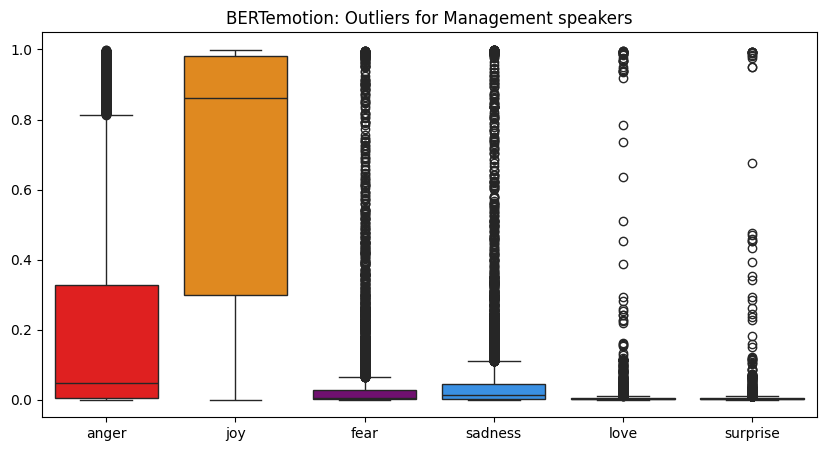

In [16]:
# Look for outliers in emotions of ubs_data where speaker_role = "management"
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize outliers of last 6 columns (emotions) using boxplots
# Display as vertical boxes on the same plot
management_data = data[data['speaker_role'] == 'management']
plt.figure(figsize=(10, 5))
sns.boxplot(data=management_data.iloc[:, -6:], palette=emotion_palette)
plt.title("BERTemotion: Outliers for Management speakers")
plt.show()

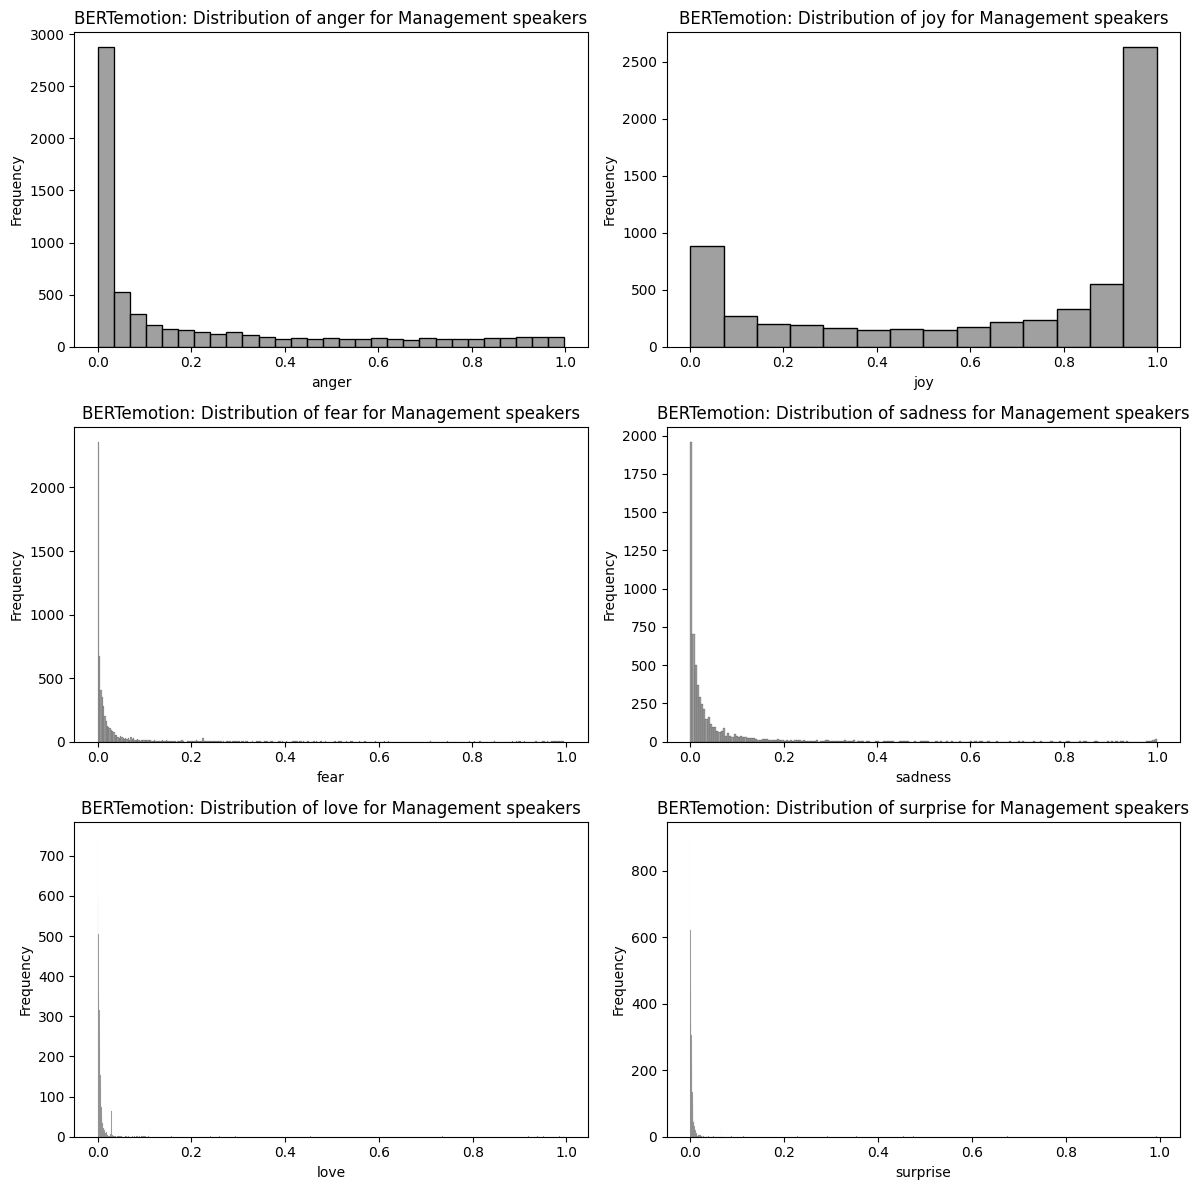

In [17]:
# Create a 3x2 grid of histograms for each emotion column
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
emotion_columns = management_data.columns[-6:]
for i, emotion in enumerate(emotion_columns):
    ax = axes[i // 2, i % 2]
    sns.histplot(data=management_data, x=emotion, ax=ax, color='grey')
    ax.set_xlabel(emotion)
    ax.set_ylabel('Frequency')
    ax.set_title(f"BERTemotion: Distribution of {emotion} for Management speakers")
plt.tight_layout()
plt.show()

## Calculate quarterly statistics (Management not Analyst)

In [18]:
# Create dataframe to calculate median and standard deviation of every emotion every quarter (UBS)
emotion_stats = data.groupby(["quarter", "main_emotion", "speaker_role","section"]).agg(
    median_score=("main_emotion_score", "median"),
    std_score=("main_emotion_score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()

# Drop rows where speaker_role = analyst
emotion_stats = emotion_stats[emotion_stats['speaker_role'] != 'analyst']
emotion_stats.head(10)   

,quarter,main_emotion,speaker_role,section,median_score,std_score
1,2022-Q1,anger,management,prepared,0.590989,0.168869
2,2022-Q1,anger,management,qa,0.775346,0.179462
3,2022-Q1,anger,operator,prepared,0.586195,0.070570
4,2022-Q1,anger,operator,qa,0.919689,0.209108
6,2022-Q1,fear,management,prepared,0.995227,0.000000
7,2022-Q1,fear,management,qa,0.788288,0.205140
8,2022-Q1,fear,operator,qa,0.907927,0.000000
10,2022-Q1,joy,management,prepared,0.917361,0.163256
11,2022-Q1,joy,management,qa,0.946906,0.166721
12,2022-Q1,joy,operator,prepared,0.803937,0.160731


In [19]:
# Calculate max and mean values for std_score
emotion_std_max = emotion_stats.groupby('main_emotion')['std_score'].max()
emotion_std_mean = emotion_stats.groupby('main_emotion')['std_score'].mean()
print("Max std_score per emotion:")
print(emotion_std_max)
print("\nMean std_score per emotion:")
print(emotion_std_mean)

Max std_score per emotion:
main_emotion
anger       0.339602
fear        0.433263
joy         0.240235
love        0.183075
sadness     0.304342
surprise    0.430872
Name: std_score, dtype: float64

Mean std_score per emotion:
main_emotion
anger       0.157586
fear        0.150287
joy         0.151348
love        0.029092
sadness     0.172710
surprise    0.092587
Name: std_score, dtype: float64


## Differences between Prepared and Q&A sections for all emotions

In [20]:
# Calculate differences between prepared and QA emotion scores for UBS management if NaN use zero
diff_emotion_stats = emotion_stats.pivot_table(index=['quarter', 'main_emotion'], columns='section', values='median_score').reset_index()
diff_emotion_stats = diff_emotion_stats.fillna(0)
diff_emotion_stats['diff'] = diff_emotion_stats['qa'] - diff_emotion_stats['prepared']

In [21]:
# Find max standard deviation from all emotions from emotion_std_max values
all_emotion_std_max = emotion_std_max.max()
print("Value for error bars: ", all_emotion_std_max)

Value for error bars:  0.43326294348992594


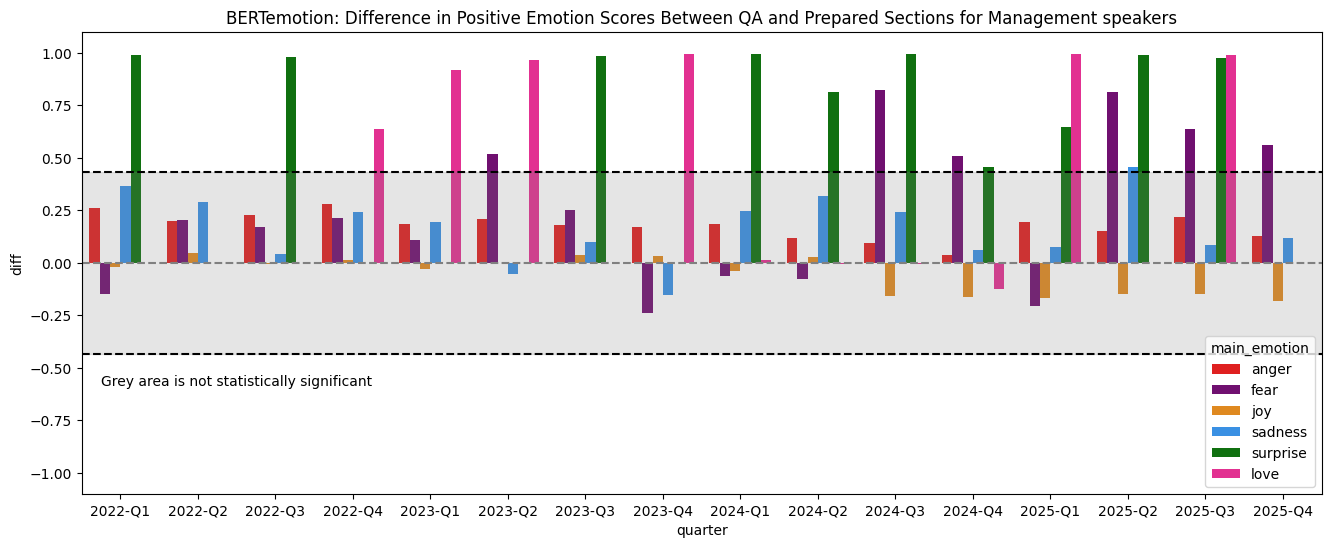

In [65]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
# fix y axis from 1.1 to -1.1
plt.ylim(-1.1, 1.1)
sns.barplot(data=diff_emotion_stats, x="quarter", y="diff", hue="main_emotion", palette=emotion_palette)
plt.title("Difference in Emotion Scores Between QA and Prepared Sections - Management (Excluding Analysts)")
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of positive emotion standard deviation
plt.axhline(all_emotion_std_max, linestyle='--', color='black')
plt.axhline(-all_emotion_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -all_emotion_std_max,
    all_emotion_std_max,
    color='grey',
    alpha=0.2
)

plt.title("BERTemotion: Difference in Positive Emotion Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=1.5, 
    y=-0.6, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)

# Save figure
plt.savefig("difference_in_emotion_scores_management.png")

## Positive Emotions
In order to build a comparison with FinBert, the BertEmotion categories will be split into:  
* POSITIVE = Love & Joy

### Median positive emotions over time

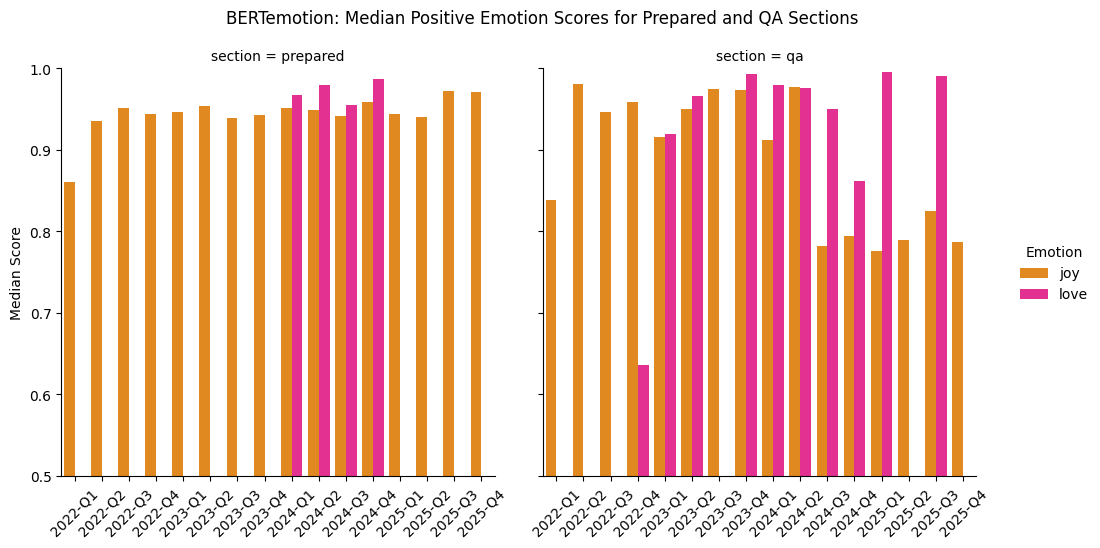

In [23]:
# Plot Positive Emotion Scores for prepared and QA sections using "Joy" and "Love" emotions

positive_emotions = ["joy", "love"]
emotion_positive = emotion_stats[emotion_stats['main_emotion'].isin(positive_emotions)].copy()

g = sns.catplot(
    kind="bar",
    data=emotion_positive,
    col="section",
    x="quarter",
    y="median_score",
    hue="main_emotion",
    palette=emotion_palette,
    errorbar=None,
)

# set y limits
g.set(ylim=(0.5, 1))
# Plot x labels at 45 degree
g.set_xticklabels(rotation=45)
# Set y label as Median Score
g.set_ylabels("Median Score")
# Remove x title
g.set_xlabels("")
g.legend.set_title("Emotion")
g.fig.suptitle("BERTemotion: Median Positive Emotion Scores for Prepared and QA Sections", y=1.05)
plt.show()

### Changes in positive emotions over time


Find worst case scenario using maximum standard deviation from "joy" and "love"

In [24]:
# Find max standard deviation for "joy" and "love" emotions from emotion_std_max values
positive_emotion_std_max = emotion_std_max[emotion_std_max.index.isin(['joy', 'love'])].max()
print("Value for error bars: ", positive_emotion_std_max)

Value for error bars:  0.24023505651991248


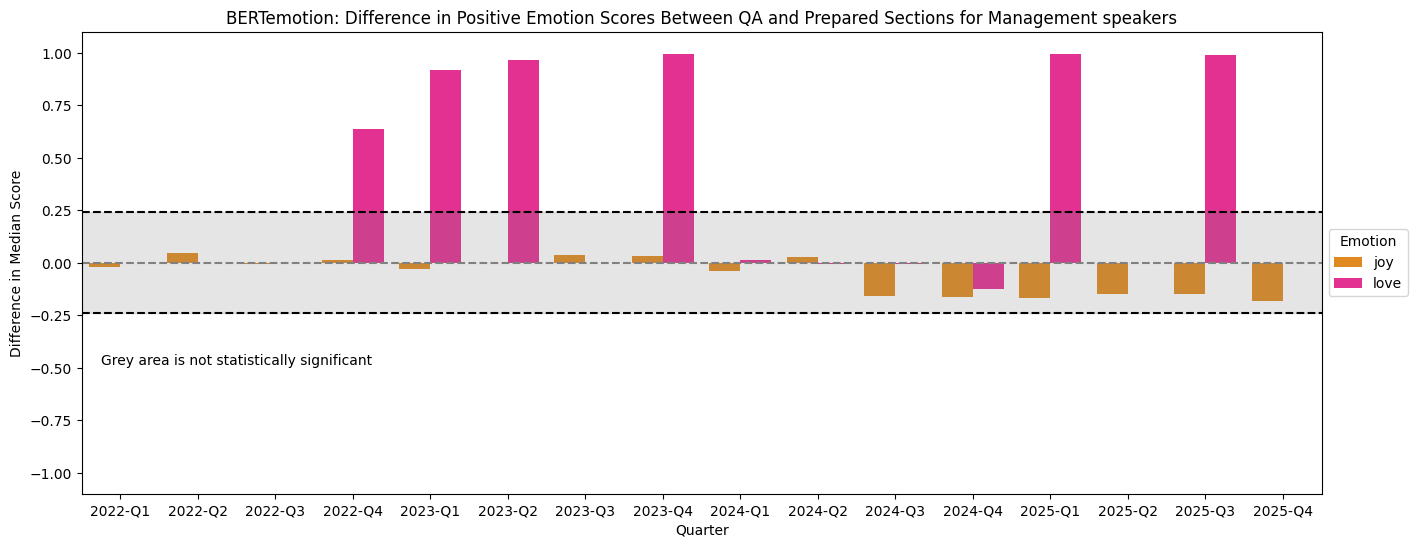

In [66]:
# Plot results as bar chart for "joy" and "love" emotions only
diff_positive_emotion_stats = diff_emotion_stats[diff_emotion_stats['main_emotion'].isin(['joy', 'love'])]
plt.figure(figsize=(16, 6))
sns.barplot(data=diff_positive_emotion_stats, x="quarter", y="diff", hue="main_emotion", palette=emotion_palette)
# fix y axis as -1.1 to +1.1
plt.ylim(-1.1, 1.1)
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of positive emotion standard deviation
plt.axhline(positive_emotion_std_max, linestyle='--', color='black')
plt.axhline(-positive_emotion_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -positive_emotion_std_max,
    positive_emotion_std_max,
    color='grey',
    alpha=0.2
)

plt.title("BERTemotion: Difference in Positive Emotion Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=1.5, 
    y=-0.5, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)
plt.xlabel("Quarter")
plt.ylabel("Difference in Median Score")
plt.legend(title="Emotion", loc='center left', bbox_to_anchor=(1, 0.5))
# Save figure
plt.savefig("diff_positive_emotion_scores.png")
plt.show()

## Negative Emotions
In order to build a comparison with FinBert, the BertEmotion categories will be split into:  
* NEGATIVE = Anger, Fear and Sadness

### Median negative emotions over time

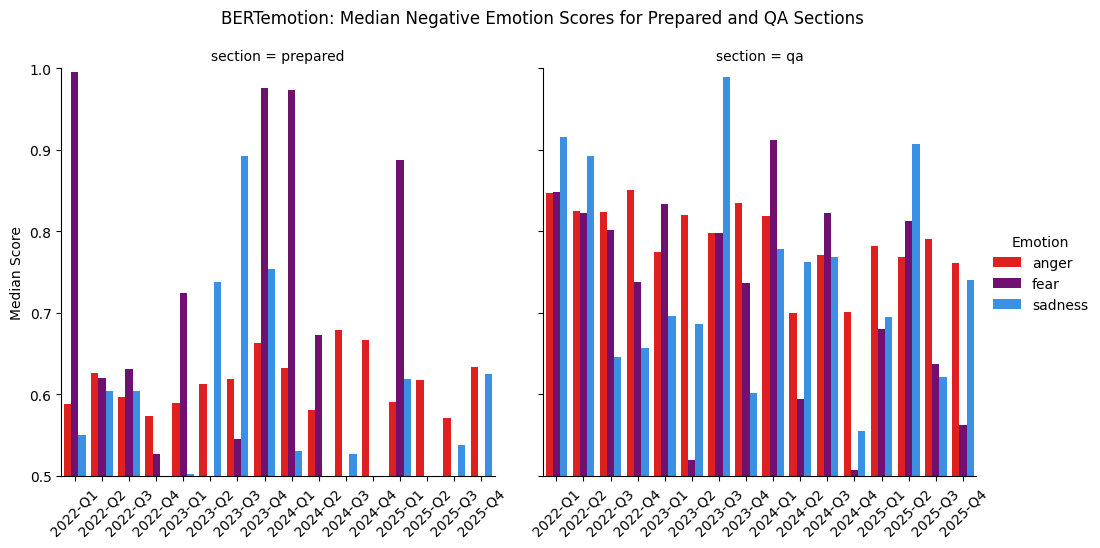

In [26]:
# Plot Negative Emotion Scores for prepared and QA sections using "Anger", "Sadness", and "Fear" emotions

negative_emotions = ["anger", "sadness", "fear"]
emotion_negative = emotion_stats[emotion_stats['main_emotion'].isin(negative_emotions)].copy()

g = sns.catplot(
    kind="bar",
    data=emotion_negative,
    col="section",
    x="quarter",
    y="median_score",
    hue="main_emotion",
    palette=emotion_palette,
    errorbar=None,
)

# set y limits
g.set(ylim=(0.5, 1))
# Plot x labels at 45 degree
g.set_xticklabels(rotation=45)
# Set y label as Median Score
g.set_ylabels("Median Score")
# Remove x title
g.set_xlabels("")
g.legend.set_title("Emotion")
g.fig.suptitle("BERTemotion: Median Negative Emotion Scores for Prepared and QA Sections", y=1.05)
plt.show()

### Changes in negative emotions over time

Find worst case scenario using maximum standard deviation from "anger", "fear" and "sadness"

In [27]:
# Find max standard deviation for "anger", "fear", "sadness" emotions from emotion_std_max values
negative_emotion_std_max = emotion_std_max[emotion_std_max.index.isin(['anger', 'fear', 'sadness'])].max()
print("Value for error bars: ", negative_emotion_std_max)

Value for error bars:  0.43326294348992594


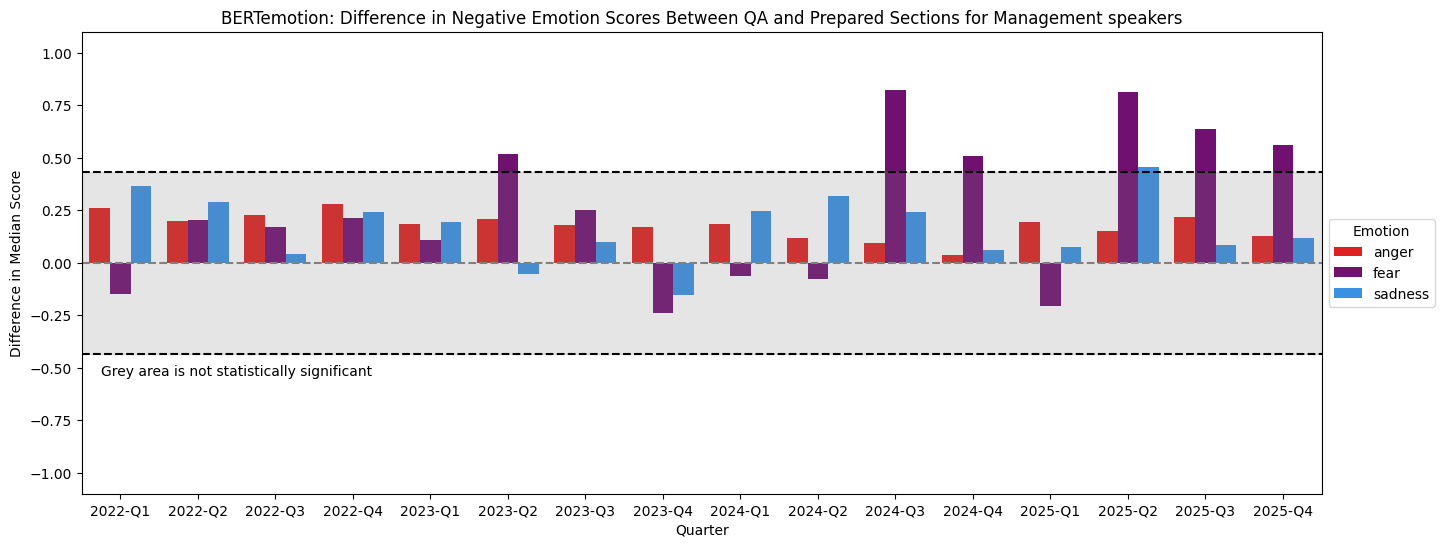

In [68]:
# Plot results as bar chart for "anger", "fear" and "sadness" emotions only
diff_negative_emotion_stats = diff_emotion_stats[diff_emotion_stats['main_emotion'].isin(['anger', 'fear', 'sadness'])]
plt.figure(figsize=(16, 6))
sns.barplot(data=diff_negative_emotion_stats, x="quarter", y="diff", hue="main_emotion", palette=emotion_palette)
# fix y axis as -1.1 to +1.1
plt.ylim(-1.1, 1.1)
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of negative emotion standard deviation
plt.axhline(negative_emotion_std_max, linestyle='--', color='black')
plt.axhline(-negative_emotion_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -negative_emotion_std_max,
    negative_emotion_std_max,
    color='grey',
    alpha=0.2
)

plt.title("BERTemotion: Difference in Negative Emotion Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=1.5, 
    y=-0.55, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)
plt.xlabel("Quarter")
plt.ylabel("Difference in Median Score")
plt.legend(title="Emotion", loc='center left', bbox_to_anchor=(1, 0.5))
# Save figure
plt.savefig("diff_negative_emotion_scores.png")
plt.show()

## Other Emotions ("Surprise")
This does not really correlate with the FinBERT classification of "Neutral"

### Median "Suprise" emotion over time

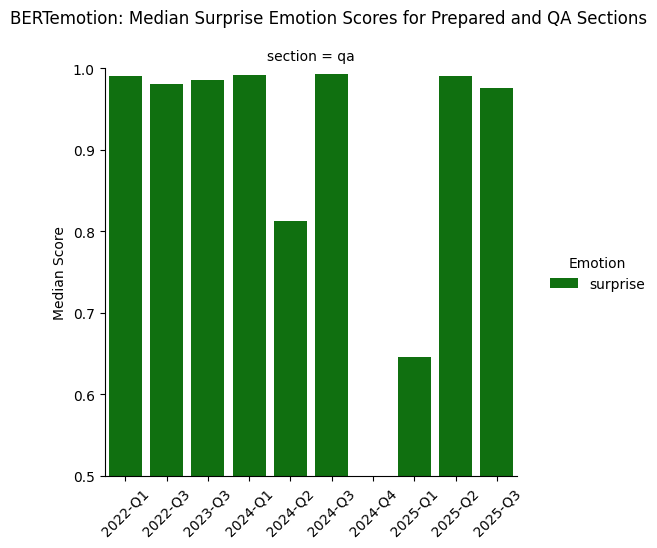

In [29]:
# Plot Surprise Emotion Scores for prepared and QA sections

surprise_emotions = ["surprise"]
emotion_surprise = emotion_stats[emotion_stats['main_emotion'].isin(surprise_emotions)].copy()

g = sns.catplot(
    kind="bar",
    data=emotion_surprise,
    col="section",
    x="quarter",
    y="median_score",
    hue="main_emotion",
    palette=emotion_palette,
    errorbar=None,
)

# set y limits
g.set(ylim=(0.5, 1))
# Plot x labels at 45 degree
g.set_xticklabels(rotation=45)
# Set y label as Median Score
g.set_ylabels("Median Score")
# Remove x title
g.set_xlabels("")
g.legend.set_title("Emotion")
g.fig.suptitle("BERTemotion: Median Surprise Emotion Scores for Prepared and QA Sections", y=1.05)
plt.show()

### Changes in surprise emotion over time

Find worst case scenario using maximum standard deviation from "surprise" - although if only one value then this will be zero

In [30]:
# Find max standard deviation for "surprise" emotions from emotion_std_max values
surprise_emotion_std_max = emotion_std_max[emotion_std_max.index.isin(['surprise'])].max()
print("Value for error bars: ", surprise_emotion_std_max)

Value for error bars:  0.43087222672841824


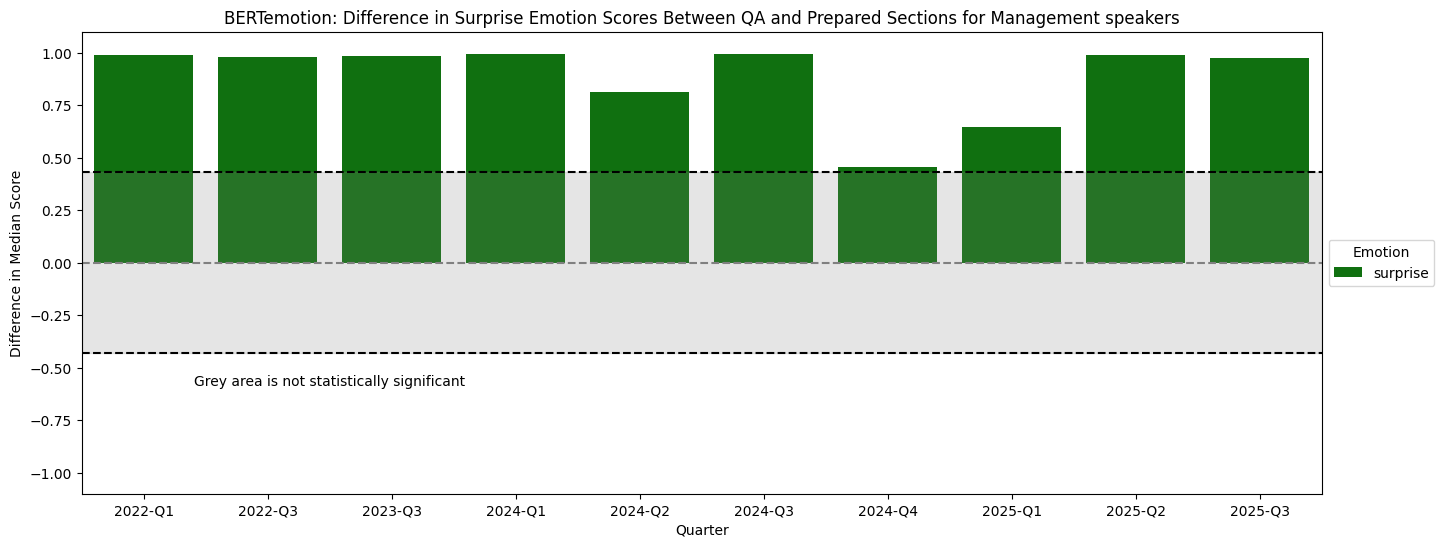

In [69]:
# Plot results as bar chart for "surprise" only
diff_negative_emotion_stats = diff_emotion_stats[diff_emotion_stats['main_emotion'].isin(['surprise'])]
plt.figure(figsize=(16, 6))
sns.barplot(data=diff_negative_emotion_stats, x="quarter", y="diff", hue="main_emotion", palette=emotion_palette)
# fix y axis as -1.1 to +1.1
plt.ylim(-1.1, 1.1)
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of surprise emotion standard deviation
plt.axhline(surprise_emotion_std_max, linestyle='--', color='black')
plt.axhline(-surprise_emotion_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -surprise_emotion_std_max,
    surprise_emotion_std_max,
    color='grey',
    alpha=0.2
)

plt.title("BERTemotion: Difference in Surprise Emotion Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of surprise emotion scores"
# Only show if value is > 0
if surprise_emotion_std_max > 0:
    plt.text(
        x=1.5, 
        y=-0.6, 
        s="Grey area is not statistically significant", 
        color='black', 
        ha='center', 
        va='bottom'
    )
plt.xlabel("Quarter")
plt.ylabel("Difference in Median Score")
plt.legend(title="Emotion", loc='center left', bbox_to_anchor=(1, 0.5))
# Save figure
plt.savefig("diff_surprise_emotion_scores.png")
plt.show()

In [32]:
# Display sentences classified as "surprise" for whole dataset, group by speaker_role
print(data[data['main_emotion'] == 'surprise'].groupby('speaker_role')['sentence'].apply(list))






speaker_role
analyst       [And just curious on how you thought about tha...
management    [...you'd be shocked., And you're always going...
Name: sentence, dtype: object


Apparently the word "Regardless" can trigger a classification of "surprise" in the model. This "catch all" emotion could therefore be comparable to FinBERT = neutral.

Note:
Domain mismatch — bhadresh-savani/bert-base-uncased-emotion was fine-tuned on general/social-media text, not financial-earnings-call language. Financial hedging language ("regardless of," "whether... or...") has no equivalent in its training distribution, so predictions on this domain are noisy and often wrong.

# RoBERTa_base Model

## Fix colours for sentiments

In [33]:
# Fix colours of bars to sentiment categories to be used in sns and matplotlib
sentiment_palette = {
    'positive': 'darkorange',
    'neutral': 'grey',
    'negative': 'dodgerblue',
}

## Build pipeline

In [34]:
# Conduct sentiment analysis using FinBERT on UBS-related financial texts
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

# Load RoBERTa-base-sentiment model and tokenizer

model_name = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Create sentiment analysis pipeline
sentiment_analyzer = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

documents = (
    data["cleaned_text"]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 67493.00it/s]


## Run the model

In [35]:
# Run the model and keep all sentiment scores
basic_sentiment = sentiment_analyzer(documents, top_k=None, truncation=True)

# Flatten the model output into one dict per sentence
sentiment_rows = []
for result in basic_sentiment:
    if isinstance(result, list):
        sentiment_rows.append({entry["label"]: entry["score"] for entry in result})
    elif isinstance(result, dict):
        sentiment_rows.append({result["label"]: result["score"]})
    else:
        sentiment_rows.append({})

# Add the top sentiment and score to the dataframe
data["main_sentiment"] = [
    max(row, key=row.get, default="LABEL_1") if row else "LABEL_1"
    for row in sentiment_rows
]
data["main_sentiment_score"] = [
    row.get(max(row, key=row.get, default="LABEL_1"), 0.0) if row else 0.0
    for row in sentiment_rows
]

# Add all sentiment columns as separate numeric columns
for sentiment in ["LABEL_0", "LABEL_1", "LABEL_2"]:
    data[sentiment] = [row.get(sentiment, 0.0) for row in sentiment_rows]
data.rename(columns={"LABEL_0": "negative", "LABEL_1": "neutral", "LABEL_2": "positive"}, inplace=True)

# Map main_sentiment to "LABEL_0": "negative","LABEL_1": "neutral" and "LABEL_2": "positive"
label_mapping = {
    "LABEL_0": "negative",
    "LABEL_1": "neutral",
    "LABEL_2": "positive",
}
data["main_sentiment"] = data["main_sentiment"].map(label_mapping)



In [36]:
data.head(10)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,joy,fear,sadness,love,surprise,main_sentiment,main_sentiment_score,negative,neutral,positive
0,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38068,...,0.662438,0.020543,0.007958,0.021985,0.010043,positive,0.852475,0.004322,0.143203,0.852475
1,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38069,...,0.994169,0.000305,0.002443,0.001968,0.000347,positive,0.730632,0.003520,0.265848,0.730632
2,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38070,...,0.203670,0.227531,0.013340,0.009466,0.009699,neutral,0.727711,0.145285,0.727711,0.127004
3,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38071,...,0.002711,0.322691,0.027531,0.003867,0.007104,neutral,0.687097,0.270609,0.687097,0.042294
4,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38072,...,0.982614,0.004017,0.003495,0.001337,0.001804,neutral,0.849775,0.035288,0.849775,0.114936
6,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38074,...,0.673268,0.012704,0.044274,0.003811,0.003194,neutral,0.897147,0.023675,0.897147,0.079178
7,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38075,...,0.803937,0.015372,0.010646,0.008209,0.006014,neutral,0.626841,0.041853,0.626841,0.331306
8,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38076,...,0.962081,0.000977,0.002873,0.029447,0.001694,neutral,0.576460,0.081310,0.576460,0.342230
9,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38077,...,0.902520,0.004542,0.007083,0.005017,0.002907,positive,0.858824,0.007220,0.133955,0.858824
10,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38078,...,0.348852,0.035924,0.013858,0.005958,0.004420,neutral,0.872353,0.049872,0.872353,0.077774


## Check outliers
Use boxplots to check shape of data for outliers. Suspect data is noisy hence using the median values rather than the mean if the data is skewed.

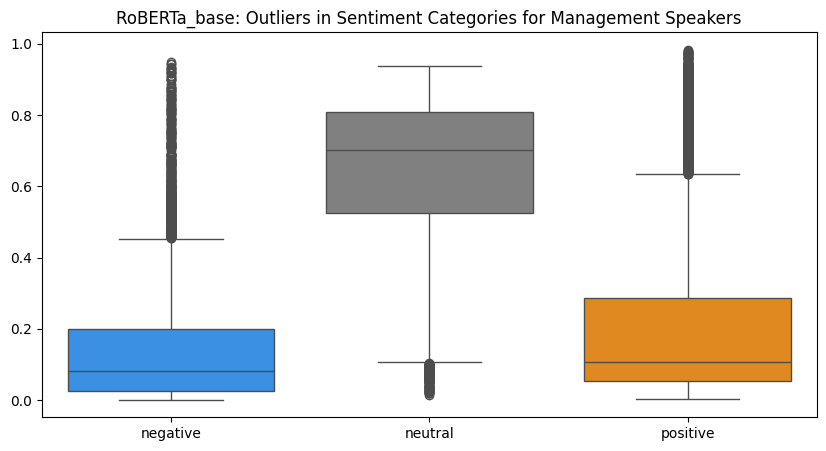

In [37]:
# Look for outliers in sentiments categories of data where speaker_role = "management"
# Display as vertical boxes on the same plot
management_data = data[data['speaker_role'] == 'management']
plt.figure(figsize=(10, 5))
sns.boxplot(data=management_data.iloc[:, -3:], palette=sentiment_palette)
plt.title("RoBERTa_base: Outliers in Sentiment Categories for Management Speakers")
plt.show()

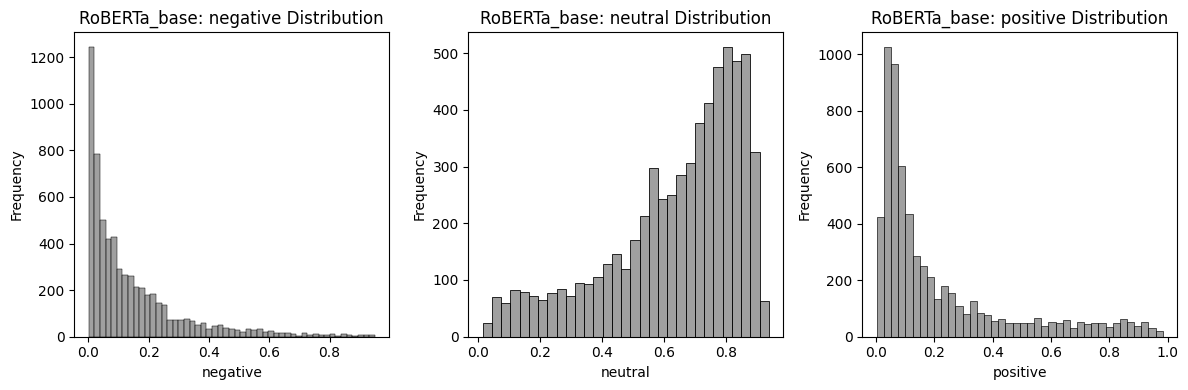

In [38]:
# Create a 1x3 grid of histograms for each sentiment category
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
emotion_columns = management_data.columns[-3:]
for i, emotion in enumerate(emotion_columns):
    ax = axes[i]
    sns.histplot(data=management_data, x=emotion, ax=ax, color='grey')
    ax.set_xlabel(emotion)
    ax.set_ylabel('Frequency')
    ax.set_title(f"RoBERTa_base: {emotion} Distribution")
plt.tight_layout()
plt.show()

The scores are highly skewed towards either end of the distribution - being either "very positive" or "very negative" but with little in the middle

In [39]:
# Calculate % of sentences in each sentiment category

management_data['positive'].sum() / len(management_data) * 100
management_data['negative'].sum() / len(management_data) * 100
management_data['neutral'].sum() / len(management_data) * 100

# display the percentage to 2 significant figures

print("Percentage of Positive sentences (Management):", round(management_data['positive'].sum() / len(management_data) * 100, 2),"%")
print("Percentage of Negative sentences (Management):", round(management_data['negative'].sum() / len(management_data) * 100, 2),"%")
print("Percentage of Neutral sentences (Management):", round(management_data['neutral'].sum() / len(management_data) * 100, 2),"%")

Percentage of Positive sentences (Management): 21.71 %
Percentage of Negative sentences (Management): 14.46 %
Percentage of Neutral sentences (Management): 63.82 %


Very little negative sentiment from the Management prepared presentation or the Q&A session

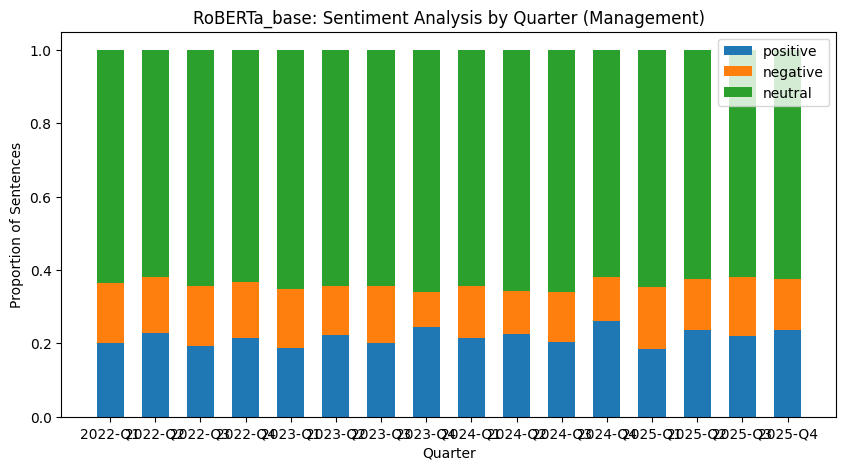

In [40]:
# Plot sentiments as a stacked bar chart for each quarter

fig, ax = plt.subplots(figsize=(10, 5))

quarters = management_data['quarter'].unique()
positive = management_data.groupby('quarter')['positive'].sum()
negative = management_data.groupby('quarter')['negative'].sum()
neutral = management_data.groupby('quarter')['neutral'].sum()

# Normalise the data for stacked bar chart
total = positive + negative + neutral
positive = positive / total
negative = negative / total
neutral = neutral / total
bar_width = 0.6
index = np.arange(len(quarters))

ax.bar(index, positive, bar_width, label='positive')
ax.bar(index, negative, bar_width, bottom=positive, label='negative')
ax.bar(index, neutral, bar_width, bottom=positive+negative, label='neutral')

ax.set_xlabel('Quarter')
ax.set_ylabel('Proportion of Sentences')
ax.set_title('RoBERTa_base: Sentiment Analysis by Quarter (Management)')
ax.set_xticks(index)
ax.set_xticklabels(quarters)
ax.legend()
plt.show()

## Calculate quarterly statistics (Management not Analyst)

In [41]:
# RoBERTa_base does not create an overall score so need to add the max value and label to end to end of data column
data['main_sentiment'] = data[['positive', 'negative', 'neutral']].idxmax(axis=1)   
data['main_sentiment_score'] = data[['positive', 'negative', 'neutral']].max(axis=1)
data.head(2)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,joy,fear,sadness,love,surprise,main_sentiment,main_sentiment_score,negative,neutral,positive
0,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38068,...,0.662438,0.020543,0.007958,0.021985,0.010043,positive,0.852475,0.004322,0.143203,0.852475
1,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38069,...,0.994169,0.000305,0.002443,0.001968,0.000347,positive,0.730632,0.003520,0.265848,0.730632


In [42]:
# Create dataframe to calculate median and standard deviation of every sentiment every quarter (UBS)
sentiment_stats = data.groupby(["quarter", "main_sentiment", "speaker_role","section"]).agg(
    median_score=("main_sentiment_score", "median"),
    std_score=("main_sentiment_score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()

# Drop rows where speaker_role = analyst
sentiment_stats = sentiment_stats[sentiment_stats['speaker_role'] != 'analyst']
sentiment_stats.head(10)   

,quarter,main_sentiment,speaker_role,section,median_score,std_score
1,2022-Q1,negative,management,prepared,0.564884,0.071156
2,2022-Q1,negative,management,qa,0.571452,0.149784
4,2022-Q1,neutral,management,prepared,0.770113,0.122113
5,2022-Q1,neutral,management,qa,0.710518,0.117690
6,2022-Q1,neutral,operator,prepared,0.727711,0.112840
7,2022-Q1,neutral,operator,qa,0.875868,0.089752
9,2022-Q1,positive,management,prepared,0.704662,0.118492
10,2022-Q1,positive,management,qa,0.757570,0.155265
11,2022-Q1,positive,operator,prepared,0.791554,0.086156
12,2022-Q1,positive,operator,qa,0.933455,0.054531


In [43]:
# Calculate max and mean values for std_score for sentiments
sentiment_std_max = sentiment_stats.groupby('main_sentiment')['std_score'].max()
sentiment_std_mean = sentiment_stats.groupby('main_sentiment')['std_score'].mean()
print("Max std_score per sentiment:")
print(sentiment_std_max)
print("\nMean std_score per sentiment:")
print(sentiment_std_mean)

Max std_score per sentiment:
main_sentiment
negative    0.161256
neutral     0.125256
positive    0.166831
Name: std_score, dtype: float64

Mean std_score per sentiment:
main_sentiment
negative    0.084970
neutral     0.101184
positive    0.103328
Name: std_score, dtype: float64


## Differences between Prepared and Q&A sections

In [44]:
# Calculate differences between prepared and QA sentiment scores for management if NaN use zero
diff_sentiment_stats = sentiment_stats.pivot_table(index=['quarter', 'main_sentiment'], columns='section', values='median_score').reset_index()
diff_sentiment_stats = diff_sentiment_stats.fillna(0)
diff_sentiment_stats['diff'] = diff_sentiment_stats['qa'] - diff_sentiment_stats['prepared']

In [45]:
diff_sentiment_stats.head(10)

section,quarter,main_sentiment,prepared,qa,diff
0,2022-Q1,negative,0.564884,0.571452,0.006569
1,2022-Q1,neutral,0.748912,0.793193,0.044281
2,2022-Q1,positive,0.748108,0.845513,0.097405
3,2022-Q2,negative,0.564702,0.629905,0.065203
4,2022-Q2,neutral,0.763431,0.765454,0.002023
5,2022-Q2,positive,0.722748,0.874624,0.151876
6,2022-Q3,negative,0.573824,0.635440,0.061615
7,2022-Q3,neutral,0.755280,0.798031,0.042750
8,2022-Q3,positive,0.750823,0.855177,0.104354
9,2022-Q4,negative,0.534180,0.601975,0.067794


In [46]:
# Find max standard deviation from all emotions from sentiment_std_max values
all_sentiment_std_max = sentiment_std_max.max()
print("Value for error bars: ", all_sentiment_std_max)

Value for error bars:  0.1668311932997709


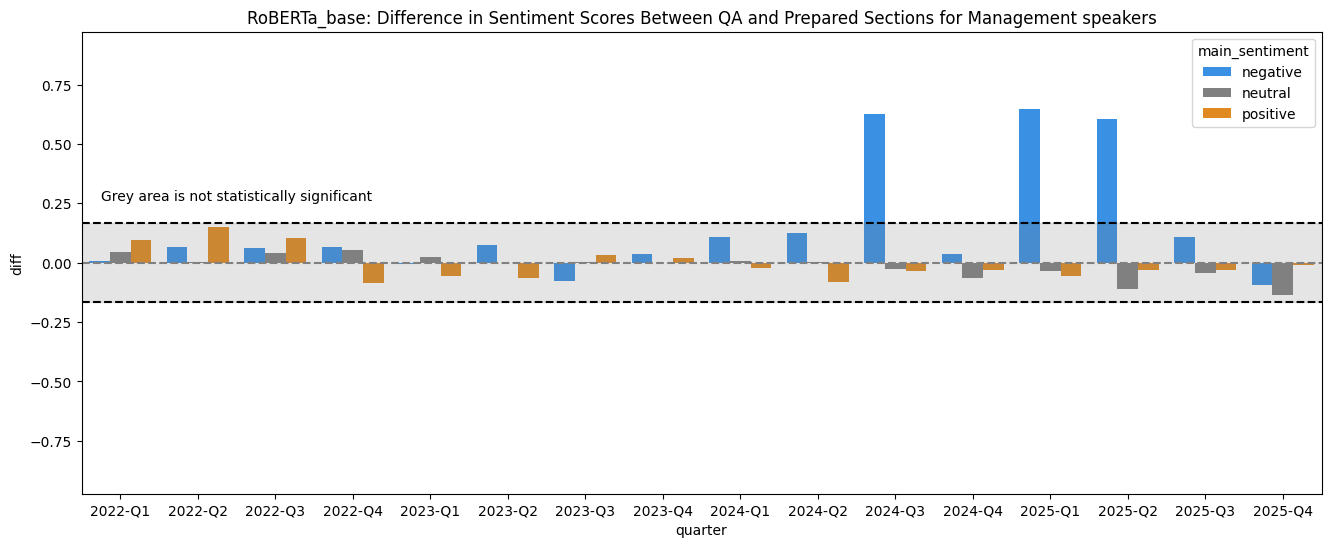

In [70]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
# fix y axis from 1.1 to -1.1
#plt.ylim(-1.1, 1.1)
sns.barplot(data=diff_sentiment_stats, x="quarter", y="diff", hue="main_sentiment", palette=sentiment_palette)

# Median scores are close to 1 in both sections, so the diff is tiny; zoom in to see it
diff_range = diff_sentiment_stats['diff'].abs().max() * 1.5
plt.ylim(-diff_range, diff_range)

plt.title("RoBERTa_base:Difference in Sentiment Scores Between QA and Prepared Sections - Management (Excluding Analysts)")
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of positive emotion standard deviation
plt.axhline(all_sentiment_std_max, linestyle='--', color='black')
plt.axhline(-all_sentiment_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -all_sentiment_std_max,
    all_sentiment_std_max,
    color='grey',
    alpha=0.2
)

plt.title("RoBERTa_base: Difference in Sentiment Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=1.5, 
    y=0.25, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)

# Save figure
plt.savefig("RoBERTa_base_difference_in_sentiment_scores_management.png")

/var/folders/c9/gw94qsq971z4r0zg7fh_c7240000gn/T/ipykernel_68307/2464939035.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=total_diff_sentiment_stats, x="main_sentiment", y="diff", palette=sentiment_palette)


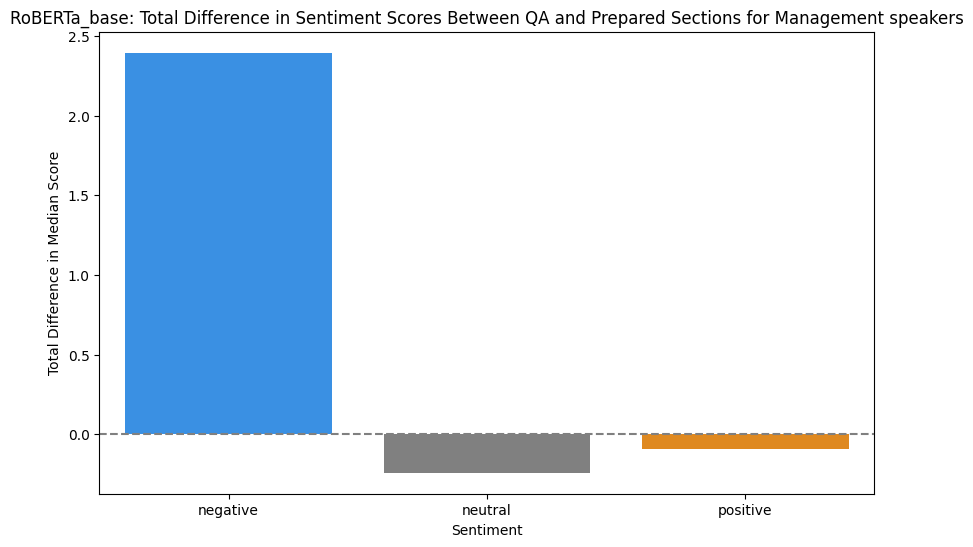

In [48]:
# Plot total sentiment differences across all quarters
total_diff_sentiment_stats = diff_sentiment_stats.groupby('main_sentiment')['diff'].sum().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=total_diff_sentiment_stats, x="main_sentiment", y="diff", palette=sentiment_palette)
plt.axhline(0, linestyle='--', color='gray')
plt.title("RoBERTa_base: Total Difference in Sentiment Scores Between QA and Prepared Sections for Management speakers")
plt.xlabel("Sentiment")
plt.ylabel("Total Difference in Median Score")
plt.savefig("RoBERTa_base_total_diff_sentiment_scores.png")
plt.show()

## Positive Sentiments

### Median positive sentiment over time

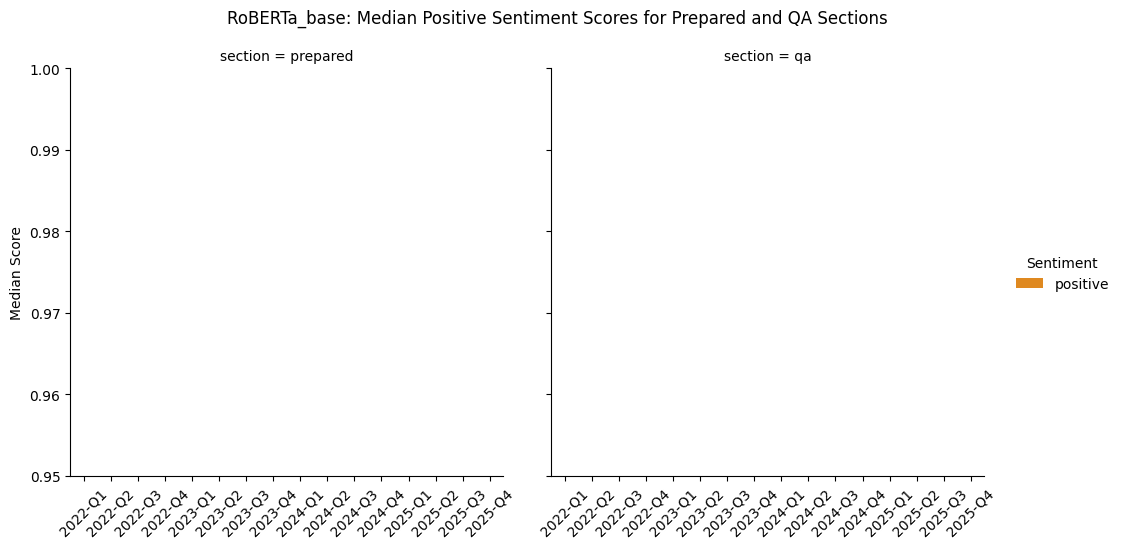

In [49]:
# Plot Positive Sentiment Scores for prepared and QA sections

positive_sentiments = ["positive"] 
positive_sentiments = sentiment_stats[sentiment_stats['main_sentiment'].isin(positive_sentiments)].copy()

g = sns.catplot(
    kind="bar",
    data=positive_sentiments,
    col="section",
    x="quarter",
    y="median_score",
    hue="main_sentiment",
    palette=sentiment_palette,
    errorbar=None,
)

# set y limits
g.set(ylim=(0.5, 1))
# Plot x labels at 45 degree
g.set_xticklabels(rotation=45)
# Set y label as Median Score
g.set_ylabels("Median Score")
# Set y limits for better visualization
g.set(ylim=(0.95, 1))
# Remove x title
g.set_xlabels("")
g.legend.set_title("Sentiment")
g.fig.suptitle("RoBERTa_base: Median Positive Sentiment Scores for Prepared and QA Sections", y=1.05)
plt.show()

### Changes in positive sentiment over time

In [50]:
# Find max standard deviation for "Positive" from sentiment_std_max values
positive_sentiment_std_max = sentiment_std_max[sentiment_std_max.index.isin(['positive'])].max()
print("Value for error bars: ", positive_sentiment_std_max)


Value for error bars:  0.1668311932997709


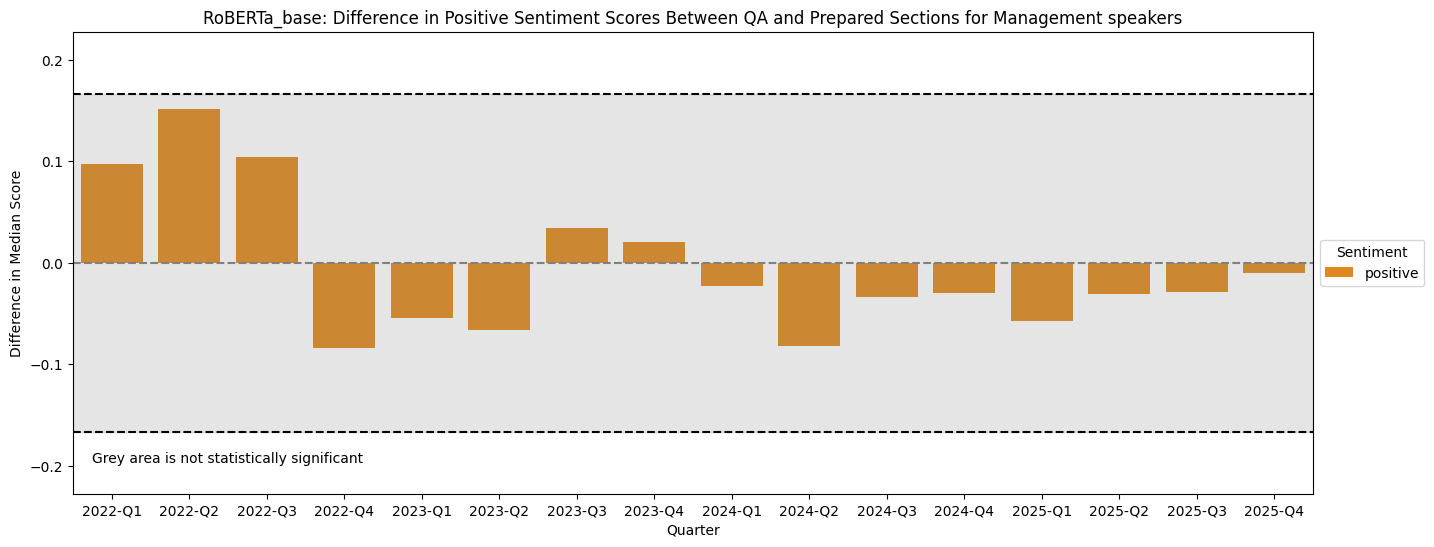

In [71]:
# Plot results as bar chart for "Positive" sentiment only
diff_positive_sentiment_stats = diff_sentiment_stats[diff_sentiment_stats['main_sentiment'].isin(['positive'])]
plt.figure(figsize=(16, 6))
sns.barplot(data=diff_positive_sentiment_stats, x="quarter", y="diff", hue="main_sentiment", palette=sentiment_palette)
# Positive median scores are close to 1 in both sections, so the diff is tiny; zoom in to see it
diff_range = diff_positive_sentiment_stats['diff'].abs().max() * 1.5
plt.ylim(-diff_range, diff_range)
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of positive sentiment standard deviation
plt.axhline(positive_sentiment_std_max, linestyle='--', color='black')
plt.axhline(-positive_sentiment_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -positive_sentiment_std_max,
    positive_sentiment_std_max,
    color='grey',
    alpha=0.2
)

plt.title("RoBERTa_base: Difference in Positive Sentiment Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive sentiment scores"
plt.text(
    x=1.5, 
   y=-0.2, 
   s="Grey area is not statistically significant", 
    color='black', 
   ha='center', 
    va='bottom'
)
plt.xlabel("Quarter")
plt.ylabel("Difference in Median Score")
plt.legend(title="Sentiment", loc='center left', bbox_to_anchor=(1, 0.5))
# Save figure
plt.savefig("RoBERTa_basediff_positive_sentiment_scores.png")
plt.show()

There is virtually no difference in positive sentiment between the prepared presentation and the Q&A section. Nothing is statistically significant.

## Negative Sentiments

### Median negative sentiment over time

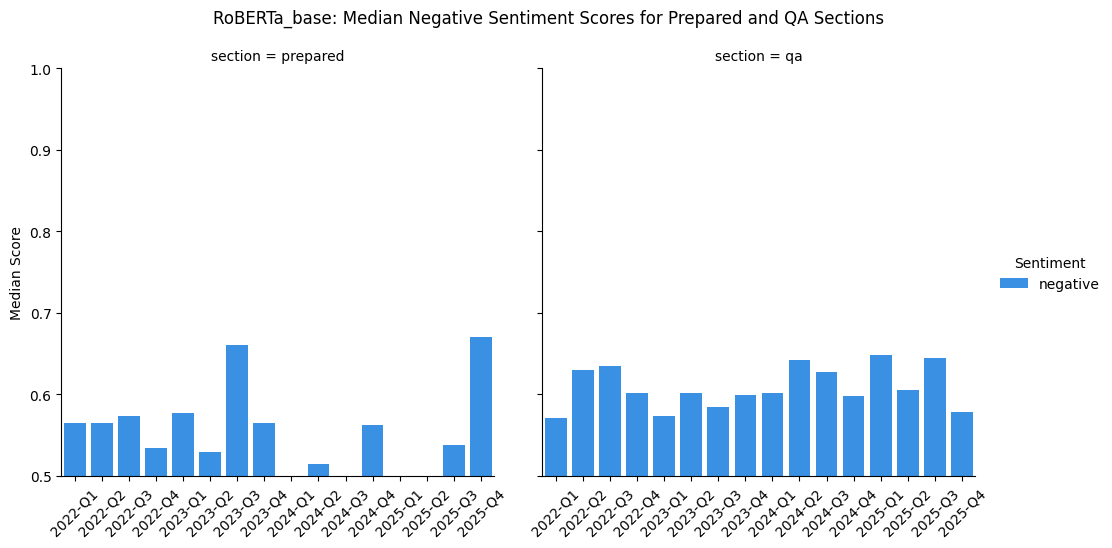

In [52]:
# Plot Negative Sentiment Scores for prepared and QA sections using "Negative" sentiment

negative_sentiment = ["negative"]
negative_sentiment = sentiment_stats[sentiment_stats['main_sentiment'].isin(negative_sentiment)].copy()

g = sns.catplot(
    kind="bar",
    data=negative_sentiment,
    col="section",
    x="quarter",
    y="median_score",
    hue="main_sentiment",
    palette=sentiment_palette,
    errorbar=None,
)

# set y limits
g.set(ylim=(0.5, 1))
# Plot x labels at 45 degree
g.set_xticklabels(rotation=45)
# Set y label as Median Score
g.set_ylabels("Median Score")
# Remove x title
g.set_xlabels("")
g.legend.set_title("Sentiment")
g.fig.suptitle("RoBERTa_base: Median Negative Sentiment Scores for Prepared and QA Sections", y=1.05)
plt.show()

### Changes in negative sentiment over time

In [53]:
# Find max standard deviation for "Negative" from sentiment_std_max values
negative_sentiment_std_max = sentiment_std_max[sentiment_std_max.index.isin(['negative'])].max()
print("Value for error bars: ", negative_sentiment_std_max)

Value for error bars:  0.1612556554944667


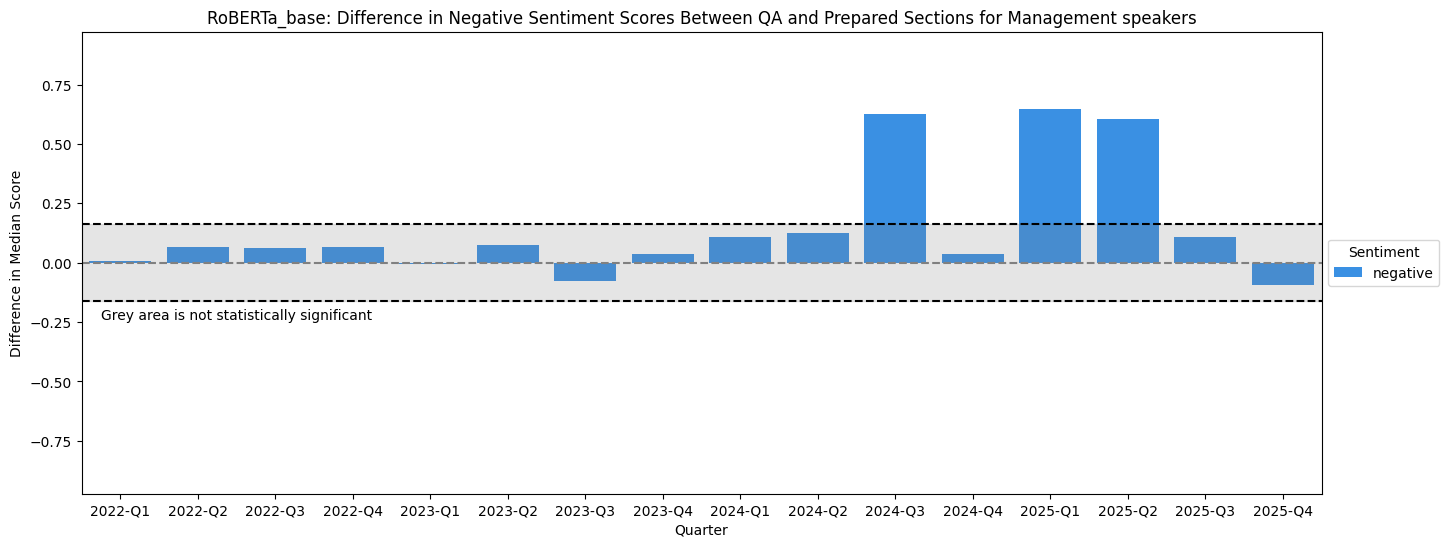

In [72]:
# Plot results as bar chart for "Negative" sentiment only
diff_negative_sentiment_stats = diff_sentiment_stats[diff_sentiment_stats['main_sentiment'].isin(['negative'])]
plt.figure(figsize=(16, 6))
sns.barplot(data=diff_negative_sentiment_stats, x="quarter", y="diff", hue="main_sentiment", palette=sentiment_palette)
# Negative median scores are close to 1 in both sections, so the diff is tiny; zoom in to see it
diff_range = diff_negative_sentiment_stats['diff'].abs().max() * 1.5
plt.ylim(-diff_range, diff_range)
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of negative sentiment standard deviation
plt.axhline(negative_sentiment_std_max, linestyle='--', color='black')
plt.axhline(-negative_sentiment_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -negative_sentiment_std_max,
    negative_sentiment_std_max,
    color='grey',
    alpha=0.2
)

plt.title("RoBERTa_base: Difference in Negative Sentiment Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive sentiment scores"
plt.text(
    x=1.5, 
   y=-0.25, 
   s="Grey area is not statistically significant", 
    color='black', 
   ha='center', 
    va='bottom'
)
plt.xlabel("Quarter")
plt.ylabel("Difference in Median Score")
plt.legend(title="Sentiment", loc='center left', bbox_to_anchor=(1, 0.5))
# Save figure
plt.savefig("RoBERTa_basediff_negative_sentiment_scores.png")
plt.show()

Again, there are no statistically significant changes in sentiment between the prepared presentation and the Q&A section

## Neutral Sentiments

### Median neutral emotions over time

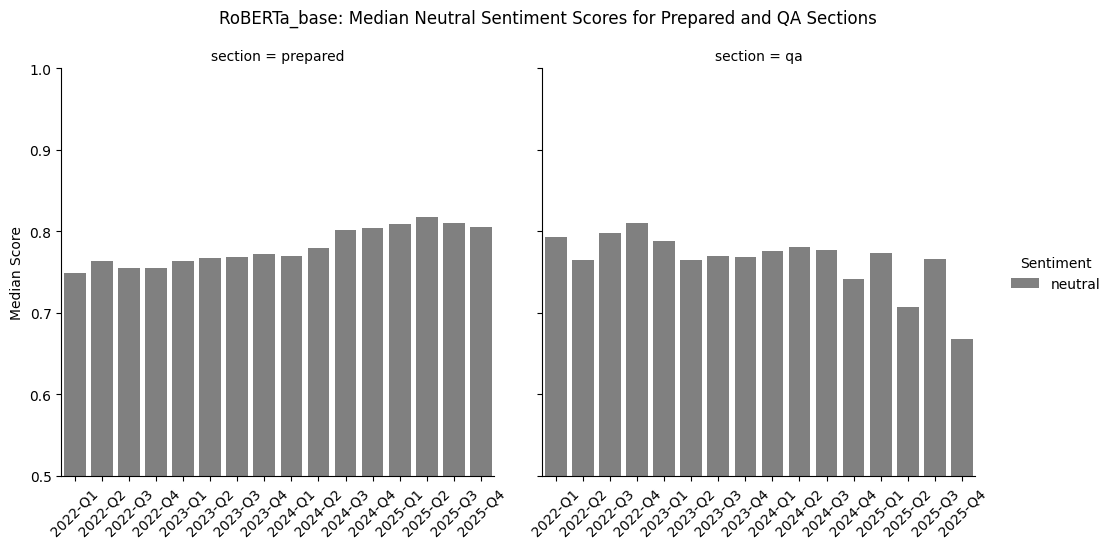

In [55]:
# Plot Neutral Sentiment Scores for prepared and QA sections using "Neutral" sentiment

neutral_sentiment = ["neutral"]
neutral_sentiment = sentiment_stats[sentiment_stats['main_sentiment'].isin(neutral_sentiment)].copy()

g = sns.catplot(
    kind="bar",
    data=neutral_sentiment,
    col="section",
    x="quarter",
    y="median_score",
    hue="main_sentiment",
    palette=sentiment_palette,
    errorbar=None,
)

# set y limits
g.set(ylim=(0.5, 1))
# Plot x labels at 45 degree
g.set_xticklabels(rotation=45)
# Set y label as Median Score
g.set_ylabels("Median Score")
# Remove x title
g.set_xlabels("")
g.legend.set_title("Sentiment")
g.fig.suptitle("RoBERTa_base: Median Neutral Sentiment Scores for Prepared and QA Sections", y=1.05)
plt.show()

### Changes in neutral sentiment over time

In [56]:
# Find max standard deviation for "Neutral" from sentiment_std_max values
neutral_sentiment_std_max = sentiment_std_max[sentiment_std_max.index.isin(['neutral'])].max()
print("Value for error bars: ", neutral_sentiment_std_max)

Value for error bars:  0.12525554228155222


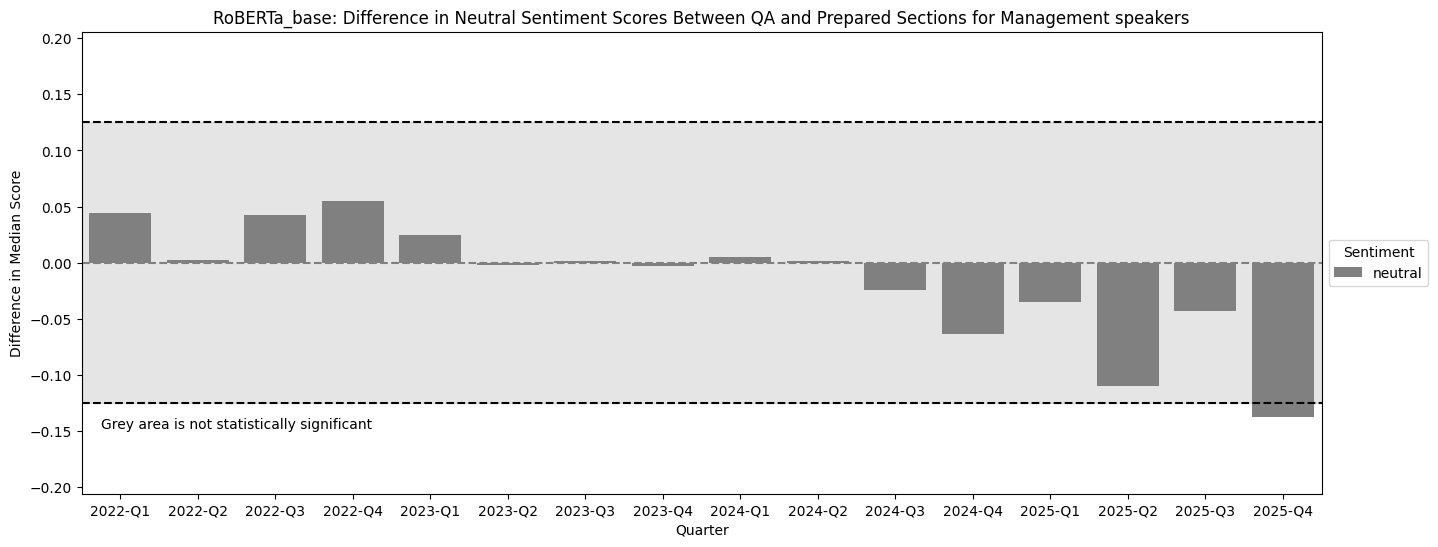

In [73]:
# Plot results as bar chart for "Neutral" sentiment only
diff_neutral_sentiment_stats = diff_sentiment_stats[diff_sentiment_stats['main_sentiment'].isin(['neutral'])]
plt.figure(figsize=(16, 6))
sns.barplot(data=diff_neutral_sentiment_stats, x="quarter", y="diff", hue="main_sentiment", palette=sentiment_palette)
# Neutral median scores are close to 1 in both sections, so the diff is tiny; zoom in to see it
diff_range = diff_neutral_sentiment_stats['diff'].abs().max() * 1.5
plt.ylim(-diff_range, diff_range)
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of neutral sentiment standard deviation
plt.axhline(neutral_sentiment_std_max, linestyle='--', color='black')
plt.axhline(-neutral_sentiment_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -neutral_sentiment_std_max,
    neutral_sentiment_std_max,
    color='grey',
    alpha=0.2
)

plt.title("RoBERTa_base: Difference in Neutral Sentiment Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive sentiment scores"
plt.text(
    x=1.5, 
   y=-0.15, 
   s="Grey area is not statistically significant", 
    color='black', 
   ha='center', 
    va='bottom'
)
plt.xlabel("Quarter")
plt.ylabel("Difference in Median Score")
plt.legend(title="Sentiment", loc='center left', bbox_to_anchor=(1, 0.5))
# Save figure
plt.savefig("RoBERTa_basediff_neutral_sentiment_scores.png")
plt.show()

# Compare RobBERTa and BERTemotion

### All sentences (Management & Analyst)

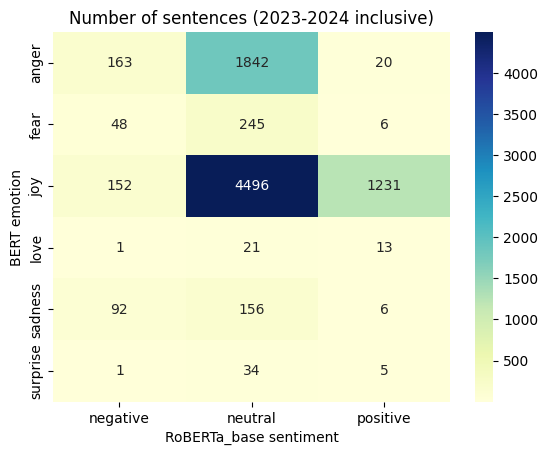

In [58]:
# Plot main_emotion and main_sentiment in data as a heatmap for comparison
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = pd.crosstab(data['main_emotion'], data['main_sentiment'])
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu")
# Label axes
plt.xlabel('RoBERTa_base sentiment')
plt.ylabel('BERT emotion')
plt.title('Number of sentences (2023-2024 inclusive)')
plt.show()



NOTES:  


* Clearly the majority of the sentences are classified by BERT-emotion as "Joy" but they are split by FinBERT into mainly "Neutral" , rather than simply "Positive".  
* Interestingly FinBERT classifies some of the "Joy" sentences as "Negative" which would need further investigation.  
* It also indicates that the large number of those classified as "Anger" are also "Neutral" in a financial context
* This is repeated in a smaller sense for "Sadness"


### Management sentences only

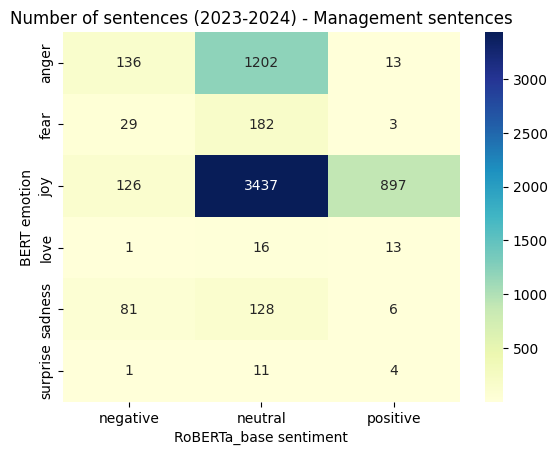

In [59]:
# Plot main_emotion and main_sentiment in data as a heatmap for comparison but only management sentences
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = pd.crosstab(data.loc[data['speaker_role'] == 'management', 'main_emotion'], 
                           data.loc[data['speaker_role'] == 'management', 'main_sentiment'])
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu")
# Label axes
plt.xlabel('RoBERTa_base sentiment')
plt.ylabel('BERT emotion')
plt.title('Number of sentences (2023-2024) - Management sentences')
plt.show()

This shows a very similar pattern to all the sentences in the data.  

* The one sentence classified as "Surprise" by BERTemotion was classified as "Neutral" by FinBERT

### Compare Model output on Q&A and Prepared sections

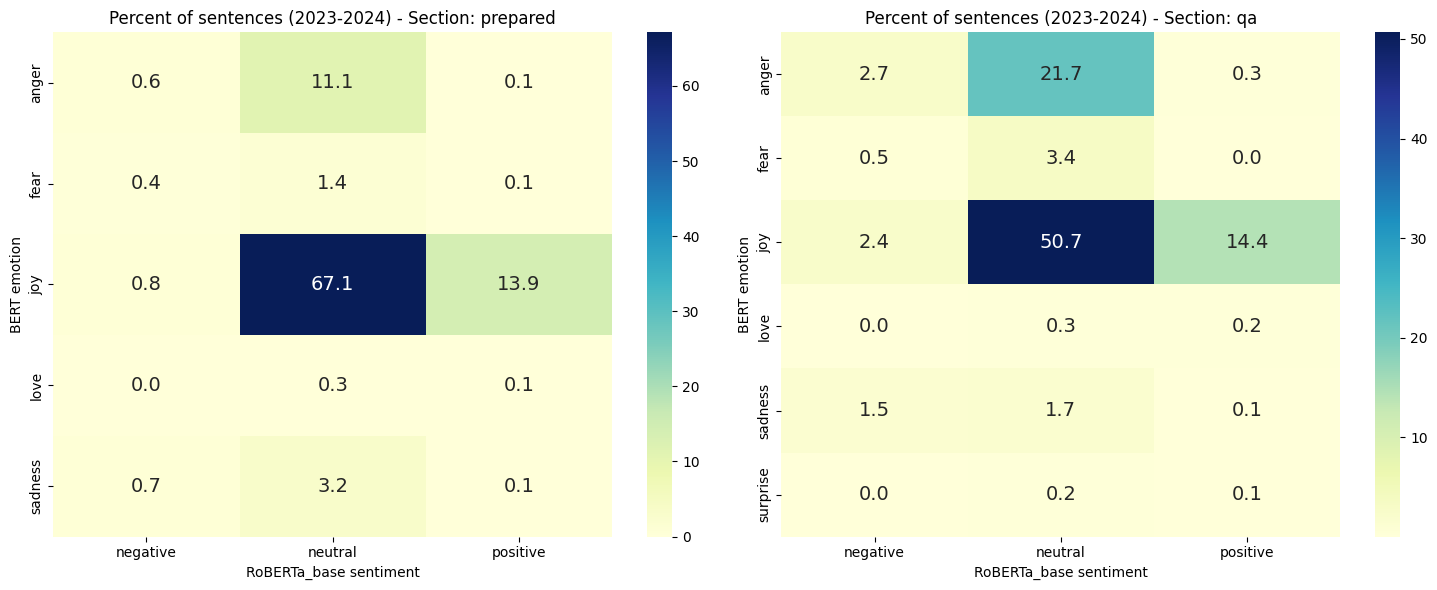

In [74]:
# Create two heatmaps side by side with speaker_role = management but split by section
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Display values as % of total number and use large font for annotations
sections = data['section'].unique()
for i, section in enumerate(sections[:2]):  # Only take the first two sections for side by side comparison
    heatmap_data = pd.crosstab(
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_emotion'],
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_sentiment']
    )
    heatmap_data = heatmap_data / heatmap_data.values.sum() * 100  # Convert to percentage
    sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[i], annot_kws={"size": 14})
    axes[i].set_xlabel('RoBERTa_base sentiment')
    axes[i].set_ylabel('BERT emotion')
    axes[i].set_title(f'Percent of sentences (2023-2024) - Section: {section}')

plt.tight_layout()

# Save each subplot as its own image using its extent, plus the combined figure
for i, section in enumerate(sections[:2]):
    extent = axes[i].get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(f'heatmap_management_section_{section}.png', bbox_inches=extent)
fig.savefig('heatmaps_management_sections.png')
plt.show()

FinBERT = positive and BERTemotion = "joy" is straightforward to understand, however FinBERT = neutral and BERTemotion = "anger" needs further investigation

## Investigate Q&A sentences where FinBERT = Neutral but BERTemotion = Anger

In [61]:
# Create dataframe of sentences where main_emotion = "anger" and main_sentiment = "Neutral" for management where section = qa
df_anger_neutral = data[(data['main_emotion'] == 'anger') & (data['main_sentiment'] == 'neutral') & (data['speaker_role'] == 'management') & (data['section'] == 'qa')]

df_anger_neutral['cleaned_text'].head(5)

106                      [want, run, bottomsup, process]
114    [else, equal, youll, see, headwind, fed, hike,...
115                                              [noisy]
117                   [thats, dont, focus, much, number]
135    [saw, rwa, inflation, market, risk, weve, talk...
Name: cleaned_text, dtype: object

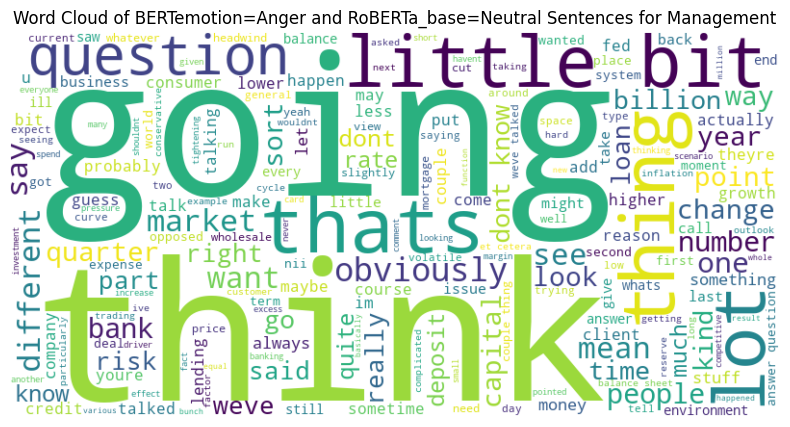

In [62]:
# Create a word cloud of sentences where main_emotion = "anger" and main_sentiment = "Neutral" for management
from wordcloud import WordCloud

# cleaned_text holds token lists, so flatten each row before joining
text = " ".join(word for tokens in df_anger_neutral['cleaned_text'] for word in tokens)
wordcloud = WordCloud(width=800, height=400, background_color ='white').generate(text)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud of BERTemotion=Anger and RoBERTa_base=Neutral Sentences for Management')
plt.axis('off')
# Save figure
plt.savefig('wordcloud_anger_neutral_management_qa.png')
plt.show()

# Final Scorecard
To demonstrate the comparison of the models

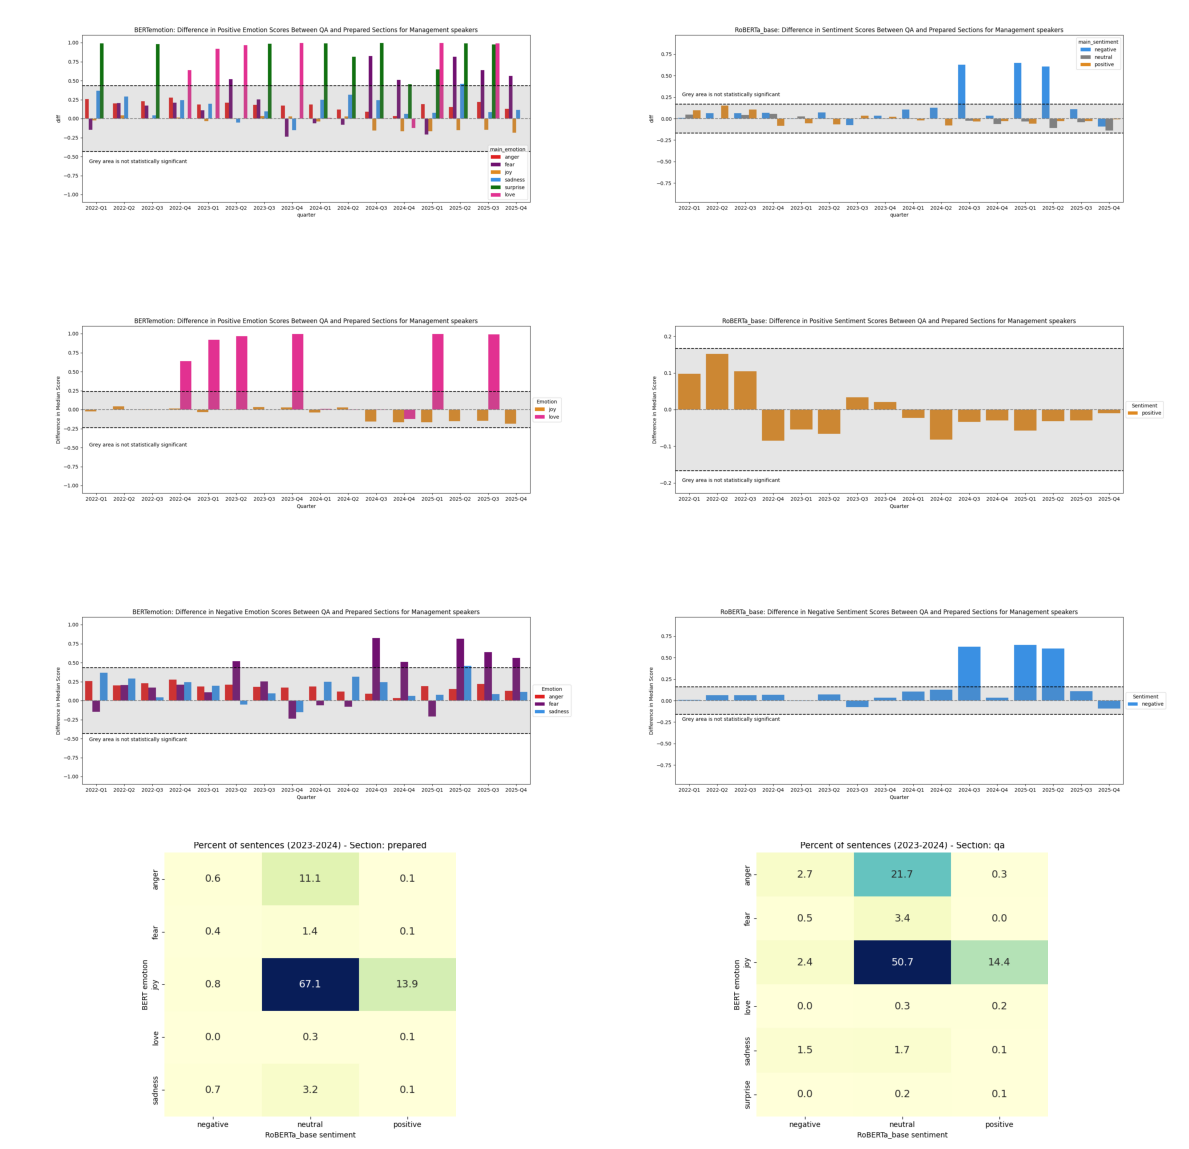

In [75]:
# Build scorecard of 3x2 subplots
fig, axes = plt.subplots(4, 2, figsize=(12, 12))
metrics = met['metric_name'].unique()

# Plot [0,0] as BERTemotion - all
img_trq = plt.imread('difference_in_emotion_scores_management.png')
axes[0, 0].imshow(img_trq)
axes[0, 0].axis('off')


# Plot [0,1] as RoBERTa_base - all
img_np = plt.imread('RoBERTa_base_difference_in_sentiment_scores_management.png')
axes[0, 1].imshow(img_np)
axes[0, 1].axis('off')


# Plot [1,0] as BERTemotion - positive
img_tt = plt.imread('diff_positive_emotion_scores.png')
axes[1, 0].imshow(img_tt)
axes[1, 0].axis('off')


# Plot [1,1] as RoBERTa_base - positive
img_se = plt.imread('RoBERTa_basediff_positive_sentiment_scores.png')
axes[1, 1].imshow(img_se)
axes[1, 1].axis('off')

# Plot [2,0] as BERTemotion - negative
img_placeholder = plt.imread('diff_negative_emotion_scores.png')
axes[2, 0].imshow(img_placeholder)
axes[2, 0].axis('off')

# Plot [2,1] as RoBERTa_base - negative
img_placeholder2 = plt.imread('RoBERTa_basediff_negative_sentiment_scores.png')
axes[2, 1].imshow(img_placeholder2)
axes[2, 1].axis('off')

# Plot [3,0] as heatmap comparison (prepared)
img_placeholder3 = plt.imread('heatmap_management_section_prepared.png')
axes[3, 0].imshow(img_placeholder3)
axes[3, 0].axis('off')

# Plot [3,1] as heatmap comparison (QA)
img_placeholder4 = plt.imread('heatmap_management_section_qa.png')
axes[3, 1].imshow(img_placeholder4)
axes[3, 1].axis('off')



plt.tight_layout()
# Save the scorecard figure
plt.savefig('scorecard_BERTemotion_vs_RoBERTa_base.png')
plt.show()